In [2]:
import matplotlib.pyplot as plt
import numpy as np
import utils
import random

audio_paths = [
    f"../music-clips/classical_{i}.wav" for i in range(1,17) ] + [
    f"../music-clips/electronic_{i}.wav" for i in range(1,17)
]

model, processor = utils.load_music_gen_model()
wfs = utils.load_process_bulk_audio(audio_paths, sr=32000)
inputs_dict = utils.process_bulk_music_gen(wfs, processor=processor)

attentions_dict = utils.extract_attentions(model, inputs_dict)
mad_dict = utils.compute_mad_dict(attentions_dict)

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.


Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

In [4]:
import pickle
with open("mad_data.pkl", "wb") as f:
        pickle.dump(mad_dict, f)

In [ ]:
import pandas as pd
import seaborn as sns

# Sample expected schema conversion:
# Adjust keys inside this function to match your exact nested dict layout.
def mad_dict_to_dataframe(mad_dict):
    records = []
    
    # Example structure: mad_dict[genre][piece_id][layer][head]
    for genre, pieces in mad_dict.items():
        for piece_id, layers in pieces.items():
            for layer_idx, heads in layers.items():
                for head_idx, mad_val in heads.items():
                    records.append({
                        "genre": genre,
                        "piece_id": piece_id,
                        "layer": int(layer_idx),
                        "head": int(head_idx),
                        "mad": float(mad_val)
                    })
                    
    return pd.DataFrame(records)

# --- Plotting Distributions ---
def plot_genre_distributions(df, save_plot=True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Density Plot (KDE)
    sns.kdeplot(
        data=df, 
        x="mad", 
        hue="genre", 
        common_norm=False, 
        fill=True, 
        alpha=0.4, 
        ax=axes[0]
    )
    axes[0].set_title("MAD Density Distribution by Genre")
    axes[0].set_xlabel("Mean Attention Distance (MAD)")
    axes[0].set_ylabel("Density")
    
    # 2. Layer-wise Breakdown (Boxplot across layers)
    sns.boxplot(
        data=df, 
        x="layer", 
        y="mad", 
        hue="genre", 
        ax=axes[1], 
        fliersize=1
    )
    axes[1].set_title("MAD Distribution across Layers")
    axes[1].set_xlabel("Layer Index")
    axes[1].set_ylabel("MAD")
    
    plt.tight_layout()
    if save_plot:
        plt.savefig("mad_genre_distribution.png", dpi=300)
    plt.show()

# --- Summary Statistics ---
def print_genre_stats(df):
    stats = df.groupby("genre")["mad"].agg(["count", "mean", "std", "median", "iqr" if hasattr(pd.Series, "iqr") else lambda x: x.quantile(0.75) - x.quantile(0.25)])
    print("=== MAD Summary Statistics by Genre ===")
    print(stats)

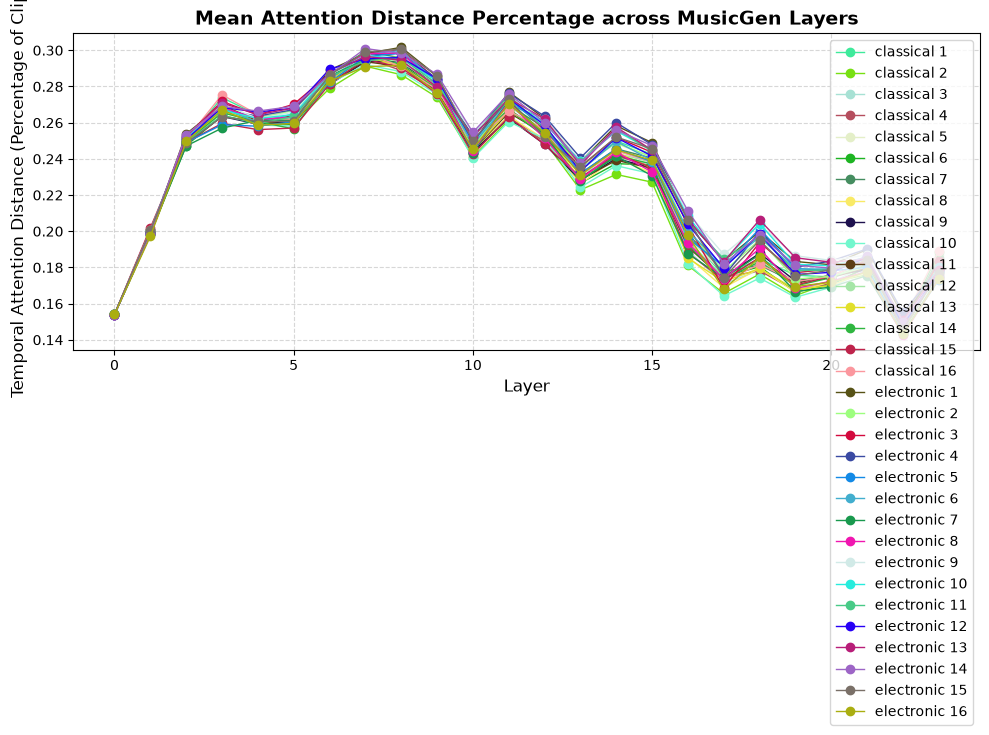

In [ ]:
plt.figure(figsize=(10, 6))

for path, mads in mad_dict.items():
    random_hex = f"#{random.randint(0, 0xFFFFFF):06x}"
    num_layers = len(mad_dict.get(path))
    layer_averages = np.mean(mads, axis=1)
    label = path.replace("../music-clips/", "").replace("_", " ").replace(".wav", "")
    plt.plot(range(num_layers), layer_averages, color=random_hex, linewidth=1, marker='o', label=label)

plt.title("Mean Attention Distance Percentage across MusicGen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Layer", fontsize=12)
plt.ylabel("Temporal Attention Distance (Percentage of Clip)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(),
plt.tight_layout()